**5/24/26** 
---------------------------------------------------------------------------------------------------------------------------------------------------------

**Introduction:**

* Question:

1.) What is Logistic Regression?

2.) Supervised Learning? 

3.) Binary classification?    


* Answer:


1) Logistic Regression

  A supervised classification algorithm that predicts the probability that an input belongs to a particular class. Despite the name "regression," it's used
  for classification.

  It works by:
  - Taking a linear combination of features: $z = w_1x_1 + w_2x_2 + \dots + b$
  - Passing it through the sigmoid function: $\sigma(z) = \frac{1}{1 + e^{-z}}$
  - This squashes the output to a value between 0 and 1 (a probability)
  - A threshold (usually 0.5) decides the final class

  Trained by minimizing log loss (cross-entropy) via gradient descent.

  ---
  2) Supervised Learning

  A machine learning paradigm where the model learns from labeled data — each training example has an input $x$ and a known correct output $y$.

  - Goal: learn a function $f(x) \approx y$ that generalizes to new, unseen inputs
  - Two main types:
    - Classification — predict a discrete label (spam / not spam)
    - Regression — predict a continuous value (house price)
  - Examples: logistic regression, decision trees, neural networks, SVMs

  Contrast with unsupervised learning (no labels, e.g., clustering) and reinforcement learning (learn from rewards).

  ---
  3) Binary Classification

  A classification task where there are exactly two possible classes — typically labeled 0/1, True/False, or Positive/Negative.

  Examples:
  - Email → spam or not spam
  - Tumor → malignant or benign
  - Transaction → fraud or legitimate

  Common evaluation metrics:
  - Accuracy
  - Precision / Recall
  - F1 score
  - ROC-AUC

  Logistic regression is one of the most common algorithms used for binary classification.



* Codecademy Outputs:

Supervised learning is a type of machine learning in which a model is trained on labeled data. Each example in the data has input features and a known output (label). The model learns to predict the output from the inputs. Common tasks include classification (predicting categories) and regression (predicting numbers).

Logistic regression is a supervised learning algorithm used for classification tasks. It predicts the probability that a data point belongs to a certain class, usually between 0 and 1. If the probability exceeds a threshold (e.g., 0.5), the data point is assigned to one class; otherwise, it is assigned to the other. It is commonly used for binary classification problems.


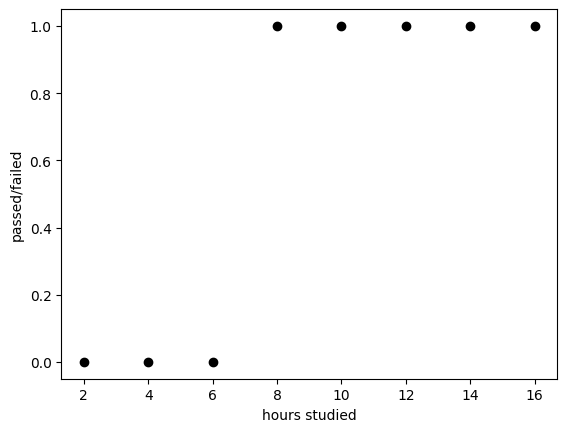

In [1]:
# Ex.) 

import pandas as pd
import matplotlib.pyplot as plt

# Create sample data
data = {
    'hours_studied': [2, 4, 6, 8, 10, 12, 14, 16],
    'passed_exam': [0, 0, 0, 1, 1, 1, 1, 1]
}
codecademyU = pd.DataFrame(data)

# Scatter plot
plt.scatter(codecademyU['hours_studied'], codecademyU['passed_exam'], color='black')
plt.ylabel('passed/failed')
plt.xlabel('hours studied')
plt.show()


**Linear Regression Approach:**

# Why Linear Regression Isn't Ideal for Classification

  - Linear regression fits a straight line to predict outcomes based on input features.
  - For binary outcomes (like pass/fail), linear regression can predict values outside 0 and 1, which is not ideal.
  - The model uses an equation:

  $$y = b_0 + b_1x_1$$

  - Linear regression is not the best choice for classification tasks.
  - This lesson sets up why **logistic regression** is needed for binary outcomes.





/home/plewis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


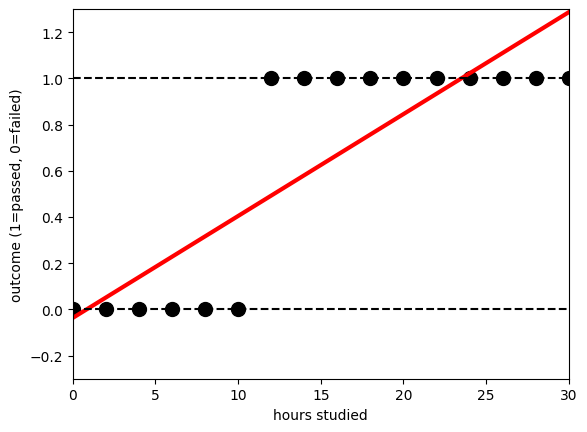

In [2]:
#Ex.) 

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Sample data
data = {
    'hours_studied': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30],
    'passed_exam':   [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

# Fit linear regression
model = LinearRegression()
model.fit(df[['hours_studied']], df[['passed_exam']])

# Predict for plotting
sample_x = np.linspace(0, 30, 100).reshape(-1, 1)
predictions = model.predict(sample_x)

# Plot
plt.scatter(df['hours_studied'], df['passed_exam'], color='black', s=100)
plt.plot(sample_x, predictions, color='red', linewidth=3)
plt.axhline(y=0, color='k', linestyle='--')
plt.axhline(y=1, color='k', linestyle='--')
plt.xlabel('hours studied')
plt.ylabel('outcome (1=passed, 0=failed)')
plt.xlim(0, 30)
plt.ylim(-0.3, 1.3)
plt.show()


#define variables 
slacker = -0.25
average = 0.5
studious =  1.75

**Logistic Regression:**


 # Logistic Regression

  - Logistic regression is used for **classification**, especially binary outcomes (like pass/fail).
  - It applies the **logit (sigmoid) function** to keep predictions between 0 and 1.
  - The equation is:

  $$\ln\left(\frac{y}{1 - y}\right) = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$$

  - The output can be interpreted as the **probability of belonging to a class**.
  - Logistic regression adapts linear regression for classification problems.

/home/plewis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


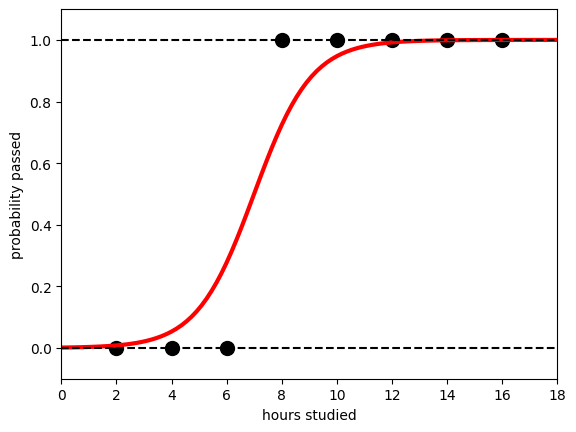

In [6]:
#Ex.) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Sample data
data = {
    'hours_studied': [2, 4, 6, 8, 10, 12, 14, 16],
    'passed_exam': [0, 0, 0, 1, 1, 1, 1, 1]
}
df = pd.DataFrame(data)

# Fit logistic regression model
model = LogisticRegression()
model.fit(df[['hours_studied']], df['passed_exam'])

# Predict probabilities for a range of hours
sample_x = np.linspace(0, 18, 100).reshape(-1, 1)
probabilities = model.predict_proba(sample_x)[:, 1]

# Plot data and logistic curve
plt.scatter(df['hours_studied'], df['passed_exam'], color='black', s=100)
plt.plot(sample_x, probabilities, color='red', linewidth=3)
plt.axhline(y=0, color='k', linestyle='--')
plt.axhline(y=1, color='k', linestyle='--')
plt.xlabel('hours studied')
plt.ylabel('probability passed')
plt.xlim(0, 18)
plt.ylim(-0.1, 1.1)
plt.show()


#variable estimate 
five_hour_studier =  0.1



**Log Odds:**

# Log-Odds (Logit) in Logistic Regression

  - Logistic regression uses **log-odds** to model probabilities.
  - **Odds** are calculated as:

  $$\text{odds} = \frac{p}{1 - p}$$

   where  **p** is the probability of the event.

  - **Log-odds (logit)** is the natural log of the odds:

  $$\text{logit}(p) = \ln\left(\frac{p}{1 - p}\right)$$

  - Log-odds can range from **negative to positive infinity**.
  - The logit function transforms probabilities (0 to 1) into a **continuous scale** for modeling.


In [8]:
#Ex.) 

import numpy as np

# Calculate odds_of_rain
p_rain = 0.4
p_not_rain = 1.0 - 0.4
odds_of_rain = p_rain/p_not_rain
print("Odds of Rain: ", odds_of_rain)



# Calculate log_odds_of_rain
log_odds_of_rain = np.log(odds_of_rain)
print("Log odds of rain: ", log_odds_of_rain)



# Calculate odds_on_time
p_train = 0.9
p_not_train = 1.0 - 0.9
odds_on_time = p_train/p_not_train
print("Odds of on-Time: ", odds_on_time)


# Calculate log_odds_on_time
log_odds_on_time = np.log(odds_on_time)
print("Log odds of on-Time: ", log_odds_on_time)



Odds of Rain:  0.6666666666666667
Log odds of rain:  -0.4054651081081643
Odds of on-Time:  9.000000000000002
Log odds of on-Time:  2.1972245773362196


**Sigmoid Function:** 



 # Sigmoid Function

  - The **sigmoid function** transforms log-odds into probabilities between 0 and 1.
  - The formula is:

  $$\sigma(x) = \frac{1}{1 + e^{-x}}$$

  - It creates an **S-shaped curve**.
  - Used in logistic regression to convert model output into a probability.
  - Values close to **0** mean low probability; values close to **1** mean high probability.

In [10]:
#Ex.) 

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# Create sample data
data = {
    'hours_studied': [2, 4, 6, 8, 10, 12, 14, 16],
    'passed_exam': [0, 0, 0, 1, 1, 1, 1, 1]
}
codecademyU = pd.DataFrame(data)

# Prepare features and target
hours_studied = codecademyU[['hours_studied']]
passed_exam = codecademyU[['passed_exam']]

# Fit logistic regression model
model = LogisticRegression()
model.fit(hours_studied, passed_exam)

# Get intercept and coefficient
intercept = model.intercept_
coef = model.coef_

# Calculate log odds
log_odds = intercept + hours_studied * coef
print(log_odds)

# Calculate predicted probability of passing
pred_probability_passing = np.exp(log_odds) / (1 + np.exp(log_odds))
print(pred_probability_passing)


   hours_studied
0      -4.805813
1      -2.882470
2      -0.959127
3       0.964216
4       2.887559
5       4.810902
6       6.734245
7       8.657588
   hours_studied
0       0.008116
1       0.053027
2       0.277053
3       0.723965
4       0.947228
5       0.991925
6       0.998812
7       0.999826


/home/plewis/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**Fitting a model in sklearn:**


In [14]:
# Codecademy Code: 

"""
# Import pandas and the data
import pandas as pd
codecademyU = pd.read_csv('codecademyU_2.csv')

# Separate out X and y
X = codecademyU[['hours_studied', 'practice_test']]
y = codecademyU.passed_exam

# Transform X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 27)

# Create and fit the logistic regression model here:
from sklearn.linear_model import LogisticRegression


# Print the intercept and coefficients here:
cc_lr = LogisticRegression()
model = cc_lr.fit(X_train, y_train)
print("The coefficents: ", model.coef_)
print("The intercepts: ", model.intercept_)

"""


'\n# Import pandas and the data\nimport pandas as pd\ncodecademyU = pd.read_csv(\'codecademyU_2.csv\')\n\n# Separate out X and y\nX = codecademyU[[\'hours_studied\', \'practice_test\']]\ny = codecademyU.passed_exam\n\n# Transform X\nfrom sklearn.preprocessing import StandardScaler\nscaler = StandardScaler()\nscaler.fit(X)\nX = scaler.transform(X)\n\n# Split data into training and testing sets\nfrom sklearn.model_selection import train_test_split\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 27)\n\n# Create and fit the logistic regression model here:\nfrom sklearn.linear_model import LogisticRegression\n\n\n# Print the intercept and coefficients here:\ncc_lr = LogisticRegression()\nmodel = cc_lr.fit(X_train, y_train)\nprint("The coefficents: ", model.coef_)\nprint("The intercepts: ", model.intercept_)\n\n'

In [12]:
#Ex.) 


# Import pandas and the data
import pandas as pd
import numpy as np

# Generate synthetic data similar to codecademyU_2.csv
np.random.seed(27)
n = 100
hours_studied = np.random.uniform(0, 20, n)
practice_test = np.random.uniform(40, 100, n)
# Pass probability depends on both features
logits = 0.4 * (hours_studied - 10) + 0.05 * (practice_test - 70)
prob = 1 / (1 + np.exp(-logits))
passed_exam = (np.random.uniform(0, 1, n) < prob).astype(int)

codecademyU = pd.DataFrame({
    'hours_studied': hours_studied,
    'practice_test': practice_test,
    'passed_exam': passed_exam
})

# Separate out X and y
X = codecademyU[['hours_studied', 'practice_test']]
y = codecademyU.passed_exam

# Transform X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=27)

# Create and fit the logistic regression model here:
from sklearn.linear_model import LogisticRegression

cc_lr = LogisticRegression()
model = cc_lr.fit(X_train, y_train)

# Print the intercept and coefficients here:
print("The coefficients: ", model.coef_)
print("The intercepts: ", model.intercept_)

The coefficients:  [[1.600784   0.80375296]]
The intercepts:  [0.67177691]


**Predictions in sklearn:**

# Predictions in Logistic Regression

  ## `.predict()` — Class Labels

  - Uses a trained model to predict whether new datapoints belong to the **positive class** (labeled `1`).
  - **Input:** a matrix of features
  - **Output:** a vector of predicted labels (`0` or `1`)

  ```python
  print(model.predict(features))
  # Sample output: [0 1 1 0 0]

  .predict_proba() — Class Probabilities

  - Returns the predicted probability of group membership instead of a hard label.
  - Input: a matrix of features
  - Output: an array of probabilities ranging from 0 to 1

  print(model.predict_proba(features)[:, 1])
  # Sample output: [0.32 0.75 0.55 0.20 0.44]

  - By default, .predict_proba() returns probabilities for both classes (one column per class).
  - Slicing [:, 1] selects only the probability of belonging to the positive class.

  Thresholding

  - Datapoints with predicted probability > 0.5 are classified as 1.
  - Datapoints with predicted probability ≤ 0.5 are classified as 0.
  - This cutoff is called the classification threshold.
  - sklearn uses a default threshold of 0.5.

  Quick Comparison

  ┌────────────────────────┬────────────────────────┬────────────────────────────────┐
  │         Method         │        Returns         │         Example Output         │
  ├────────────────────────┼────────────────────────┼────────────────────────────────┤
  │ .predict()             │ Hard class labels      │ [0, 1, 1, 0, 0]                │
  ├────────────────────────┼────────────────────────┼────────────────────────────────┤
  │ .predict_proba()[:, 1] │ Probability of class 1 │ [0.32, 0.75, 0.55, 0.20, 0.44] │
  ├────────────────────────┼────────────────────────┼────────────────────────────────┤
  │ ```                    │                        │                                │
  └────────────────────────┴────────────────────────┴────────────────────────────────┘

In [16]:
#Ex.) 

"""


# Import pandas and the data
import pandas as pd
codecademyU = pd.read_csv('codecademyU_2.csv')

# Separate out X and y
X = codecademyU[['hours_studied', 'practice_test']]
y = codecademyU.passed_exam

# Transform X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 27)

# Create and fit the logistic regression model here:
from sklearn.linear_model import LogisticRegression
cc_lr = LogisticRegression()
cc_lr.fit(X_train,y_train)

# Print out the predicted outcomes for the test data
print(cc_lr.predict(X_test))

# Print out the predicted probabilities for the test data
print(cc_lr.predict_proba(X_test)[:,1])


# Print out the true outcomes for the test data
print(y_test)


"""

"\n\n\n# Import pandas and the data\nimport pandas as pd\ncodecademyU = pd.read_csv('codecademyU_2.csv')\n\n# Separate out X and y\nX = codecademyU[['hours_studied', 'practice_test']]\ny = codecademyU.passed_exam\n\n# Transform X\nfrom sklearn.preprocessing import StandardScaler\nscaler = StandardScaler()\nscaler.fit(X)\nX = scaler.transform(X)\n\n# Split data into training and testing sets\nfrom sklearn.model_selection import train_test_split\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 27)\n\n# Create and fit the logistic regression model here:\nfrom sklearn.linear_model import LogisticRegression\ncc_lr = LogisticRegression()\ncc_lr.fit(X_train,y_train)\n\n# Print out the predicted outcomes for the test data\nprint(cc_lr.predict(X_test))\n\n# Print out the predicted probabilities for the test data\nprint(cc_lr.predict_proba(X_test)[:,1])\n\n\n# Print out the true outcomes for the test data\nprint(y_test)\n\n\n"

**Classification Thresholding:**

 # Classification Threshold

  - The **classification threshold** is the cutoff probability for assigning classes in logistic regression.
  - The **default threshold** is **0.5**:
    - Probability **≥ 0.5** → **positive class** (`1`)
    - Probability **< 0.5** → **negative class** (`0`)
  - The threshold can be **adjusted** based on the problem.
  - **Lowering the threshold** increases sensitivity to positive cases (catches more positives, but more false alarms).
  - Choosing the right threshold depends on the **consequences of false positives and false negatives**.

  ## Example Trade-offs

  | Scenario | Preferred Threshold | Why |
  |----------|--------------------:|-----|
  | Cancer screening | **Lower** (e.g., 0.3) | Missing a positive (false negative) is dangerous |
  | Spam filter | **Higher** (e.g., 0.7) | Marking real email as spam (false positive) is costly |

In [17]:
#Ex.) 


"""



# Pick an alternative threshold here:
alternative_threshold = 0.6

# Import pandas and the data
import pandas as pd
codecademyU = pd.read_csv('codecademyU_2.csv')

# Separate out X and y
X = codecademyU[['hours_studied', 'practice_test']]
y = codecademyU.passed_exam

# Transform X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 27)

# Create and fit the logistic regression model here:
from sklearn.linear_model import LogisticRegression
cc_lr = LogisticRegression()
cc_lr.fit(X_train,y_train)

# Print out the predicted outcomes for the test data
print(cc_lr.predict(X_test))

# Print out the predicted probabilities for the test data
print(cc_lr.predict_proba(X_test)[:,1])

# Print out the true outcomes for the test data
print(y_test)

#Change threshold 
alternative_threshold = 0.6

"""

"\n\n\n\n# Pick an alternative threshold here:\nalternative_threshold = 0.6\n\n# Import pandas and the data\nimport pandas as pd\ncodecademyU = pd.read_csv('codecademyU_2.csv')\n\n# Separate out X and y\nX = codecademyU[['hours_studied', 'practice_test']]\ny = codecademyU.passed_exam\n\n# Transform X\nfrom sklearn.preprocessing import StandardScaler\nscaler = StandardScaler()\nscaler.fit(X)\nX = scaler.transform(X)\n\n# Split data into training and testing sets\nfrom sklearn.model_selection import train_test_split\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 27)\n\n# Create and fit the logistic regression model here:\nfrom sklearn.linear_model import LogisticRegression\ncc_lr = LogisticRegression()\ncc_lr.fit(X_train,y_train)\n\n# Print out the predicted outcomes for the test data\nprint(cc_lr.predict(X_test))\n\n# Print out the predicted probabilities for the test data\nprint(cc_lr.predict_proba(X_test)[:,1])\n\n# Print out the true outcome

**Confusion matrix:**

# Confusion Matrix — Key Notes

  ## What It Is

  - A **table that shows how well a classification model performed** by comparing predicted labels to actual labels.
  - Most commonly used for **binary classification** (but works for multi-class too).

  ## Layout (Binary Classification)

  |                    | **Predicted: 0** | **Predicted: 1** |
  |--------------------|:----------------:|:----------------:|
  | **Actual: 0**      | True Negative (TN)  | False Positive (FP) |
  | **Actual: 1**      | False Negative (FN) | True Positive (TP)  |

  ## The Four Outcomes

  - **True Positive (TP):** model predicted `1`, actual was `1` ✓
  - **True Negative (TN):** model predicted `0`, actual was `0` ✓
  - **False Positive (FP):** model predicted `1`, actual was `0` ✗ *(Type I error — false alarm)*
  - **False Negative (FN):** model predicted `0`, actual was `1` ✗ *(Type II error — missed case)*

  ## Why It Matters

  - **Accuracy alone can be misleading** — especially with imbalanced classes.
  - The confusion matrix reveals *what kind* of mistakes the model makes, not just *how many*.

  ## Metrics Derived From It

  $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

  $$\text{Precision} = \frac{TP}{TP + FP} \quad \text{(of predicted positives, how many were right?)}$$

  $$\text{Recall (Sensitivity)} = \frac{TP}{TP + FN} \quad \text{(of actual positives, how many did we catch?)}$$

  $$\text{F1 Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

  ## In sklearn

  ```python
  from sklearn.metrics import confusion_matrix

  cm = confusion_matrix(y_test, predictions)
  print(cm)
  # [[TN  FP]
  #  [FN  TP]]

   Note: sklearn's layout puts actual values in rows and predicted values in columns, with class 0 first.

  When to Care About Which Error

  ┌──────────────────┬────────────────────────────────────┬──────────────┐
  │     Use Case     │            Worst Error             │ Optimize For │
  ├──────────────────┼────────────────────────────────────┼──────────────┤
  │ Cancer screening │ False Negative (miss a real case)  │ Recall       │
  ├──────────────────┼────────────────────────────────────┼──────────────┤
  │ Spam filter      │ False Positive (real email → spam) │ Precision    │
  ├──────────────────┼────────────────────────────────────┼──────────────┤
  │ Fraud detection  │ False Negative (let fraud through) │ Recall       │
  ├──────────────────┼────────────────────────────────────┼──────────────┤
  │ Balanced needs   │ Either                             │ F1 Score     │
  ├──────────────────┼────────────────────────────────────┼──────────────┤
  │ ```              │                                    │              │
  └──────────────────┴────────────────────────────────────┴──────────────┘

In [19]:
#Ex.)

"""
# Import pandas and the data
import pandas as pd
codecademyU = pd.read_csv('codecademyU_2.csv')

# Separate out X and y
X = codecademyU[['hours_studied', 'practice_test']]
y = codecademyU.passed_exam

# Transform X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 27)

# Create and fit the logistic regression model here:
from sklearn.linear_model import LogisticRegression
cc_lr = LogisticRegression()
cc_lr.fit(X_train,y_train)

# Save and print the predicted outcomes
y_pred = cc_lr.predict(X_test)
print('predicted classes: ', y_pred)

# Print out the true outcomes for the test data
print('true classes: ', y_test)

# Print out the confusion matrix here
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))



"""

"\n# Import pandas and the data\nimport pandas as pd\ncodecademyU = pd.read_csv('codecademyU_2.csv')\n\n# Separate out X and y\nX = codecademyU[['hours_studied', 'practice_test']]\ny = codecademyU.passed_exam\n\n# Transform X\nfrom sklearn.preprocessing import StandardScaler\nscaler = StandardScaler()\nscaler.fit(X)\nX = scaler.transform(X)\n\n# Split data into training and testing sets\nfrom sklearn.model_selection import train_test_split\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 27)\n\n# Create and fit the logistic regression model here:\nfrom sklearn.linear_model import LogisticRegression\ncc_lr = LogisticRegression()\ncc_lr.fit(X_train,y_train)\n\n# Save and print the predicted outcomes\ny_pred = cc_lr.predict(X_test)\nprint('predicted classes: ', y_pred)\n\n# Print out the true outcomes for the test data\nprint('true classes: ', y_test)\n\n# Print out the confusion matrix here\nfrom sklearn.metrics import confusion_matrix\nprint(conf

**Accuracy, Recall, Precision, F1 Score:**

In [20]:
#Ex.)

"""

# Import pandas and the data
import pandas as pd
codecademyU = pd.read_csv('codecademyU_2.csv')

# Separate out X and y
X = codecademyU[['hours_studied', 'practice_test']]
y = codecademyU.passed_exam

# Transform X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 51)

# Create and fit the logistic regression model here:
from sklearn.linear_model import LogisticRegression
cc_lr = LogisticRegression()
cc_lr.fit(X_train,y_train)

# Save and print the predicted outcomes
y_pred = cc_lr.predict(X_test)
print('predicted classes: ', y_pred)

# Print out the true outcomes for the test data
print('true classes: ', y_test)

# Print out the confusion matrix
from sklearn.metrics import confusion_matrix
print('confusion matrix: ')
print(confusion_matrix(y_test, y_pred))

# Print accuracy here:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))


# Print F1 score here:
from sklearn.metrics import f1_score
print(f1_score(y_test, y_pred))

"""


"\n\n# Import pandas and the data\nimport pandas as pd\ncodecademyU = pd.read_csv('codecademyU_2.csv')\n\n# Separate out X and y\nX = codecademyU[['hours_studied', 'practice_test']]\ny = codecademyU.passed_exam\n\n# Transform X\nfrom sklearn.preprocessing import StandardScaler\nscaler = StandardScaler()\nscaler.fit(X)\nX = scaler.transform(X)\n\n# Split data into training and testing sets\nfrom sklearn.model_selection import train_test_split\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = 51)\n\n# Create and fit the logistic regression model here:\nfrom sklearn.linear_model import LogisticRegression\ncc_lr = LogisticRegression()\ncc_lr.fit(X_train,y_train)\n\n# Save and print the predicted outcomes\ny_pred = cc_lr.predict(X_test)\nprint('predicted classes: ', y_pred)\n\n# Print out the true outcomes for the test data\nprint('true classes: ', y_test)\n\n# Print out the confusion matrix\nfrom sklearn.metrics import confusion_matrix\nprint('confus

**Review**

Logistic regression is used to perform 
binary
Preview: Docs Binary is a number system of 1s and 0s which serves as a textual representation method for giving instructions to a computers CPU. In computing and telecommunications, binary codes are used for various methods of encoding data such as turning the character strings of source code, into bit strings or instruction sets for the CPU to execute.
 classification.
Logistic regression is an extension of linear regression where we use a logit link function to fit a sigmoid curve to the data, rather than a line.
We can use the coefficients from a logistic regression model to estimate the log odds that a datapoint belongs to the positive class. We can then transform the log odds into a probability.
The coefficients of a logistic regression model can be used to estimate relative feature importance.
A classification threshold is used to determine the probabilistic cutoff for where a data sample is classified as belonging to a positive or negative class. The default cutoff in sklearn is 0.5.
We can evaluate a logistic regression model using a confusion matrix or summary 
statistics
Preview: Docs Loading link description
 such as accuracy, precision, recall, and F1 score.